<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Teste_com_o_Detector_de_Emo%C3%A7%C3%B5es_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Testando o modelo do Detector de Emoções



#### Etapa 1 - Importando as bibliotecas

In [49]:
#Importando bibliotecas necessárias
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
import zipfile

In [50]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [51]:
#importando recursos para o tensorflow
import tensorflow
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
tensorflow.__version__

'2.20.0'

### Etapa 2 - Conectando com o Drive e acessando os arquivos

In [52]:
#Etapa 2 conexão com o Drive
from google.colab import drive
drive.mount('/content/gdrive') #criação da pasta

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [53]:
#codificação para acessar e descompactar o arquivo criado
path = "/content/gdrive/My Drive/Material.zip"
zip_object = zipfile.ZipFile(file=path, mode="r") # recebe arquivos compactados
zip_object.extractall('./') #extrai para pasta raiz
zip_object.close() #liberar memória

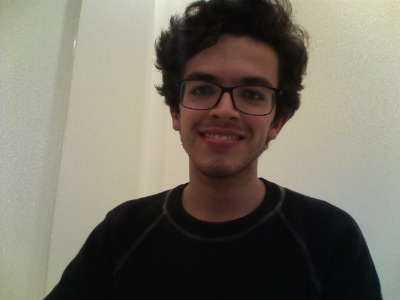

In [54]:
#carregando imagem
imagem = cv2.imread('Material/testes/teste_gabriel.png')
cv2_imshow(imagem)

In [55]:
imagem.shape

(300, 400, 3)

### Testando o Detector


###Carregamento de modelos

In [56]:
!pip install tf_keras

In [121]:
from tf_keras.models import load_model
import tensorflow

# Carregamento de modelos já pré-treinados
cascade_faces = "Material/haarcascade_frontalface_default.xml"
caminho_modelo = "Material/modelo_01_expressoes.h5"
fase_detection = cv2.CascadeClassifier(cascade_faces)
classificador_emocoes = load_model(caminho_modelo, compile = False)

# 7 categorias
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]

### Detecção de Faces

In [93]:
#Detecção de faces
original = imagem.copy() #cópia da imagem original
faces = fase_detection.detectMultiScale(original, scaleFactor = 1.1,
                                        minNeighbors = 3, minSize = (20,20)) # numero min de vizinhos de detecção e tamano min da faces

In [94]:
faces

array([[162,  40, 128, 128]], dtype=int32)

In [95]:
len(faces)

1

In [96]:
faces.shape

(1, 4)

### Extração do ROI (Region of interest)

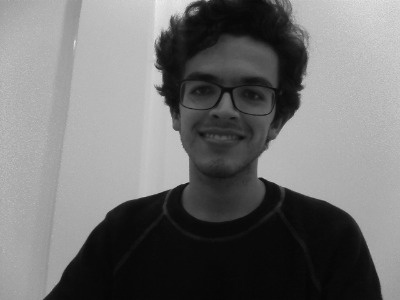

In [97]:
#Escala de cinza
cinza = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
cv2_imshow(cinza) #conversão da imagem original para cor cinza

In [98]:
cinza.shape #com a escala cinza tem somente um canal diferente do RGB

(300, 400)

In [99]:
roi = cinza[40:40 + 128, 162:162 + 128]#extração do ROI

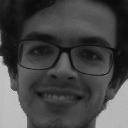

In [100]:
cv2_imshow(roi) #mostrando somente a face

In [101]:
roi.shape #dimensões da imagem

(128, 128)

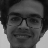

In [102]:
roi = cv2.resize(roi, (48, 48)) #diminuiu a dimensinalidade da imagem
cv2_imshow(roi)

In [103]:
roi.dtype #reultado é que os dados são numeros inteiros

dtype('uint8')

In [104]:
roi = roi.astype('float') #convertendo para float
roi.dtype

dtype('float64')

In [105]:
roi

array([[ 33.,  29.,  38., ...,  16.,  22.,  25.],
       [ 32.,  37.,  37., ...,  16.,  20.,  25.],
       [ 32.,  36.,  31., ...,  17.,  21.,  25.],
       ...,
       [186., 189., 189., ..., 181., 181., 180.],
       [185., 188., 189., ..., 180., 181., 180.],
       [185., 188., 188., ..., 179., 180., 181.]])

In [106]:
roi = roi / 255

In [107]:
roi

array([[0.12941176, 0.11372549, 0.14901961, ..., 0.0627451 , 0.08627451,
        0.09803922],
       [0.1254902 , 0.14509804, 0.14509804, ..., 0.0627451 , 0.07843137,
        0.09803922],
       [0.1254902 , 0.14117647, 0.12156863, ..., 0.06666667, 0.08235294,
        0.09803922],
       ...,
       [0.72941176, 0.74117647, 0.74117647, ..., 0.70980392, 0.70980392,
        0.70588235],
       [0.7254902 , 0.7372549 , 0.74117647, ..., 0.70588235, 0.70980392,
        0.70588235],
       [0.7254902 , 0.7372549 , 0.7372549 , ..., 0.70196078, 0.70588235,
        0.70980392]])

In [108]:
roi = img_to_array(roi)

In [109]:
roi

array([[[0.12941177],
        [0.11372549],
        [0.14901961],
        ...,
        [0.0627451 ],
        [0.08627451],
        [0.09803922]],

       [[0.1254902 ],
        [0.14509805],
        [0.14509805],
        ...,
        [0.0627451 ],
        [0.07843138],
        [0.09803922]],

       [[0.1254902 ],
        [0.14117648],
        [0.12156863],
        ...,
        [0.06666667],
        [0.08235294],
        [0.09803922]],

       ...,

       [[0.7294118 ],
        [0.7411765 ],
        [0.7411765 ],
        ...,
        [0.70980394],
        [0.70980394],
        [0.7058824 ]],

       [[0.7254902 ],
        [0.7372549 ],
        [0.7411765 ],
        ...,
        [0.7058824 ],
        [0.70980394],
        [0.7058824 ]],

       [[0.7254902 ],
        [0.7372549 ],
        [0.7372549 ],
        ...,
        [0.7019608 ],
        [0.7058824 ],
        [0.70980394]]], dtype=float32)

In [110]:
roi.shape #indica que temos 1 canal

(48, 48, 1)

In [111]:
roi = np.expand_dims(roi, axis = 0)

In [112]:
roi.shape #adicionou outra dimensão

(1, 48, 48, 1)

### Previsões

In [124]:
preds = classificador_emocoes.predict(roi)[0] #retorna uma probabilidade por emoção
#ao adicionar o 0 ele indica que está puxando a primeira posição

1/1 [==============================] - 0s 213ms/step


In [114]:
preds #retorna uma probabilidade para cada classe

array([1.6802096e-05, 5.7679665e-09, 1.1206557e-05, 9.9066460e-01,
       1.8033754e-05, 1.8518243e-05, 9.2708124e-03], dtype=float32)

In [115]:
len(preds) #idicação de quantas classes tem

7

In [116]:
emotion_probability = np.max(preds)
emotion_probability

np.float32(0.9906646)

In [117]:
preds.argmax() #onde está a posição do maior valor

np.int64(3)

In [123]:
label = expressoes[preds.argmax()]
label #visualiza qual emoção

'Feliz'

### Resultados

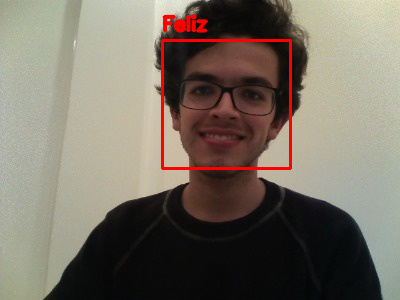

In [127]:
cv2.putText(original, label, (162, 40 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.65,
            (0, 0, 255), 2, cv2.LINE_AA)
cv2.rectangle(original, (162,40), (162 + 128, 40 + 128), (0,0,255), 2)
cv2_imshow(original)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
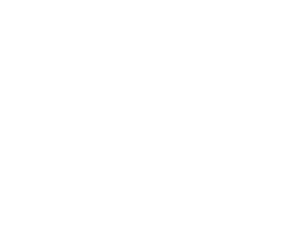

In [128]:
probabilidades = np.ones((250,300,3), dtype = 'uint8') * 255
probabilidades

In [129]:
probabilidades.shape

(250, 300, 3)

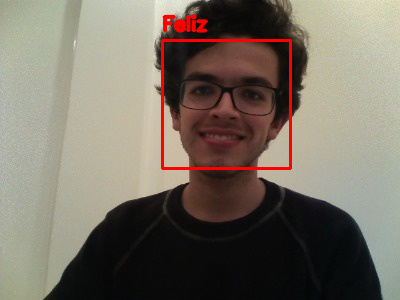

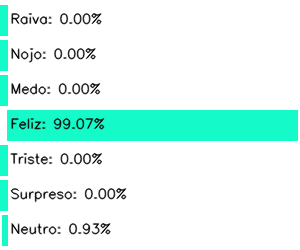

In [133]:
cv2_imshow(original)
if len(faces) == 1:
  for(i, (emotion, prob,)) in enumerate(zip(expressoes, preds)):
    #print(i, emotion, prob)
    text = "{}: {:.2f}%".format(emotion, prob * 100)
    w = int(prob * 300)
    cv2.rectangle(probabilidades, (7, (i * 35) + 5), (w, (i * 35) + 35), (200, 250, 20), -1)
    cv2.putText(probabilidades, text, (10, (i * 35) + 23), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)
cv2_imshow(probabilidades)